In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:


def prepare_hospital_data(patients_path, services_path, schedule_path):
    # 1. Load Data
    patients_df = pd.read_csv(patients_path)
    services_df = pd.read_csv(services_path)
    schedule_df = pd.read_csv(schedule_path)
    
    # 2. Date Processing & Length of Stay 
    patients_df['arrival_date'] = pd.to_datetime(patients_df['arrival_date'])
    patients_df['departure_date'] = pd.to_datetime(patients_df['departure_date'])
    patients_df['length_of_stay'] = (patients_df['departure_date'] - patients_df['arrival_date']).dt.days
    
    # 3. Aggregate Patient Data to Weekly level
    min_date = patients_df['arrival_date'].min()
    patients_df['week'] = ((patients_df['arrival_date'] - min_date).dt.days // 7) + 1
    weekly_los = patients_df.groupby(['week', 'service'])['length_of_stay'].mean().reset_index()
    weekly_los.rename(columns={'length_of_stay': 'avg_los'}, inplace=True)
    
    # 4. Aggregate Staffing to Weekly level
    weekly_staff = schedule_df.groupby(['week', 'service'])['present'].sum().reset_index()
    weekly_staff.rename(columns={'present': 'staff_on_duty'}, inplace=True)
    
    # 5. The Master Merge (Fix: Use services_df, not s_df)
    df = pd.merge(services_df, weekly_staff, on=['week', 'service'], how='left')
    df = pd.merge(df, weekly_los, on=['week', 'service'], how='left')
    
    # 6. Target & Feature Engineering
    df['utilization_rate'] = (df['patients_admitted'] / df['available_beds']).clip(upper=1.0)
    df['demand_pressure'] = df['patients_request'] / df['available_beds']
    
    # 7. Time-Series Lags
    df = df.sort_values(['service', 'week'])
    df['utilization_lag1'] = df.groupby('service')['utilization_rate'].shift(1)
    
    # 8. Handling Nulls
    df['avg_los'] = df.groupby('service')['avg_los'].transform(lambda x: x.fillna(x.median()))
    df = df.dropna(subset=['utilization_lag1'])
    
    return df



In [21]:
# Create the actual dataframe
df = prepare_hospital_data(
    '../data/patients.csv', 
    '../data/services_weekly.csv', 
    '../data/staff_schedule.csv'
)

# Look at the shape - how many rows/cols did we end up with?
print(f"Master DF Shape: {df.shape}")
df.head()

Master DF Shape: (204, 15)


,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event,staff_on_duty,avg_los,utilization_rate,demand_pressure,utilization_lag1
7,2,1,ICU,16,7,7,0,79,85,donation,30,8.250000,0.437500,0.437500,1.000000
11,3,1,ICU,20,21,20,1,82,89,none,0,5.571429,1.000000,1.050000,0.437500
15,4,1,ICU,20,21,20,1,64,85,flu,29,8.250000,1.000000,1.050000,1.000000
19,5,2,ICU,22,13,13,0,73,88,none,28,10.666667,0.590909,0.590909,1.000000
23,6,2,ICU,14,12,12,0,87,51,none,0,7.500000,0.857143,0.857143,0.590909


In [22]:
# Check Week 1 vs Week 2 for the same service
df[['week', 'service', 'utilization_rate', 'utilization_lag1']].head(10)

,week,service,utilization_rate,utilization_lag1
7,2,ICU,0.437500,1.000000
11,3,ICU,1.000000,0.437500
15,4,ICU,1.000000,1.000000
19,5,ICU,0.590909,1.000000
23,6,ICU,0.857143,0.590909
27,7,ICU,1.000000,0.857143
31,8,ICU,0.833333,1.000000
35,9,ICU,1.000000,0.833333
39,10,ICU,0.615385,1.000000
43,11,ICU,1.000000,0.615385


In [23]:
df = pd.get_dummies(df, columns=['service', 'event'], drop_first=False)

## TRAIN/TEST SPLIT

TRAIN/TEST SPLIT. This won't be a random split, I will take the first 40 weeks of history to train the model on, and test on weeks 41-52 to see if model can forecast the future. 
Will drop leaky columns such as patients admitted, and post admission outcomes like patient satisfaction. 

In [28]:
TRAIN_CUTOFF = 40

DROP_COLS = [
    'utilization_rate',
    'patients_admitted',
    'patients_refused',
    'patient_satisfaction',
    'month',
]

feature_cols = [c for c in df.columns if c not in DROP_COLS]

train = df[df['week']<= TRAIN_CUTOFF]
test = df[df['week'] > TRAIN_CUTOFF]

X_train = train[feature_cols]
y_train = train['utilization_rate']
X_test = test[feature_cols]
y_test = test['utilization_rate']

print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Features: {len(feature_cols)}")

Train: 156 rows | Test: 48 rows
Features: 16


## Model Training

For the model training, I will use gradient boosting because of its ability to handle tabular data with non-linear relationships. To optimize the model, I will utilise a time series split on the training data, this will help ensure to select the best hyperparameters. 

In [31]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [ 3,4,5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid= param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation MAE: {-grid_search.best_score_:.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best cross-validation MAE: 0.0059


In [32]:
final_model = grid_search.best_estimator_
final_preds = final_model.predict(X_test)
final_preds = np.clip(final_preds, 0, 1)
final_MAE = mean_absolute_error(y_test, final_preds)
print(F"Final Test Set MAE: {final_MAE:.4f}")


Final Test Set MAE: 0.0013


## Model Evaluation


MAE:  0.0013
RMSE: 0.0036
R²:   0.9992


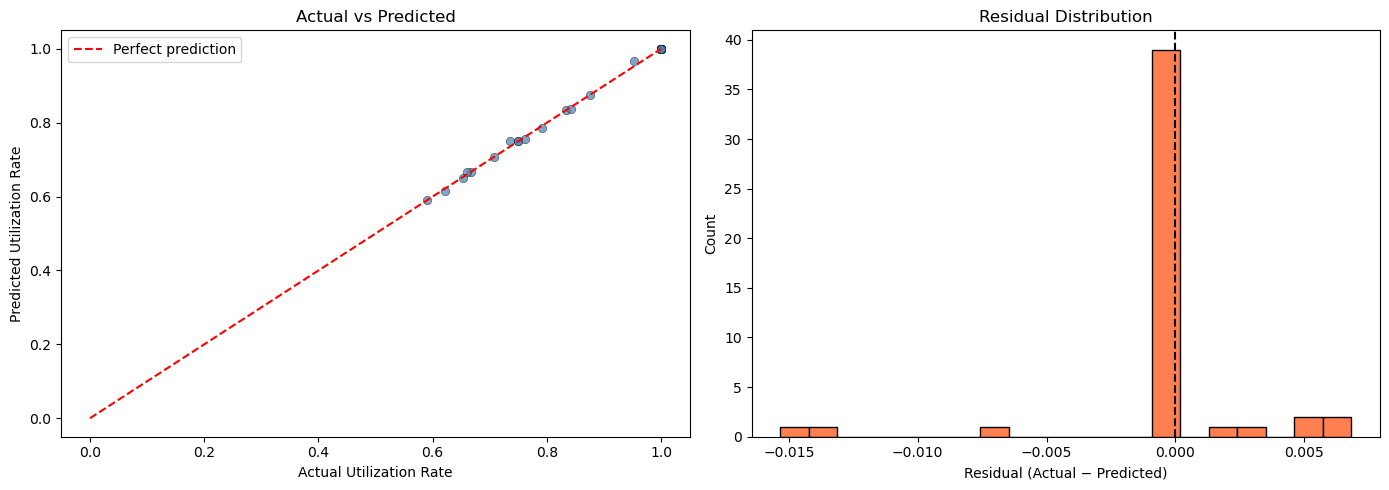

In [33]:

 
y_pred = np.clip(final_model.predict(X_test), 0, 1)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
 
print(f"\nMAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
 
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(y_test, y_pred, alpha=0.7, edgecolors='k', linewidths=0.4, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Utilization Rate')
axes[0].set_ylabel('Predicted Utilization Rate')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=20, color='coral', edgecolor='k')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
 
plt.tight_layout()
plt.show()
 

As the model is nearly perfect, it is expected because the data was very flat and uniuformly distributed, as utilization rate and weekly occupancy are nearly the same. To check if the model is at least learning and not just a mirror, i will use a baseline prediction, use last week's value for this week. 

In [ ]:
# Create a 'Dumb' prediction, using last week's value for this week
baseline_preds = X_test['utilization_lag1']
baseline_mae = mean_absolute_error(y_test, baseline_preds)

print(f"Dumb Baseline MAE (Last Week = This Week): {baseline_mae:.4f}")
print(Model's MAE: {mae:.4f}")

Dumb Baseline MAE (Last Week = This Week): 0.0959
Your Model's MAE: 0.0013


As my model MAE is lower than the baseline, it shows the model is actually learning, by synethizing multiple inputs to find signal. This shows that the issue is that the data for this task was flat, and its liley that the issue is not with the model, but to analyze how the model is reaching these conclusions I will do a feature importance check to see which features are doing the heavy lifting:

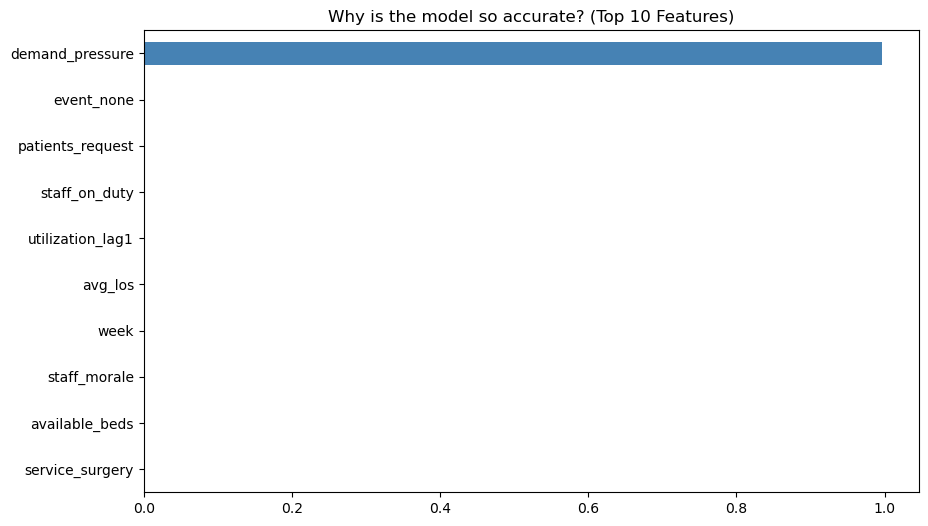

In [35]:
importances = pd.Series(final_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Why is the model so accurate? (Top 10 Features)')
plt.gca().invert_yaxis()
plt.show()

The graph above shows a huge data leak, as demand presure is accounted for 100% of feature importance, this explains the suspicous MAE. So I will remove this feature to test the model's ability to forecast based on the othe trends.

In [ ]:
experimental_features = [c for c in feature_cols if c != 'demand_pressure']

X_train_new = train[experimental_features]
X_test_new = test[experimental_features]

final_model.fit(X_train_new, y_train)
new_mae = mean_absolute_error(y_test, final_model.predict(X_test_new))

print(f"MAE without Demand Pressure: {new_mae:.4f}")

MAE without Demand Pressure: 0.0450


This proves the model is working now without the data leakage. I will visualize and observe the updated feature improtance now.

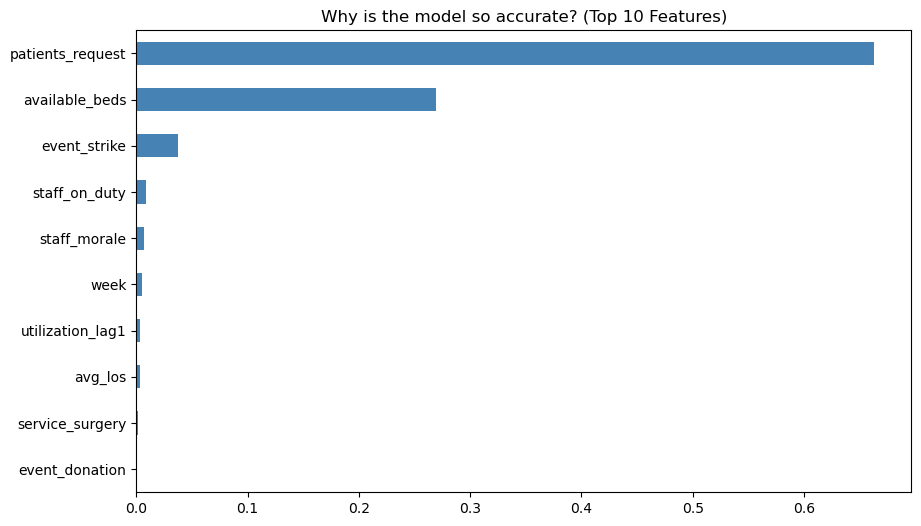

In [40]:
importances = pd.Series(final_model.feature_importances_, index=experimental_features)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Why is the model so accurate? (Top 10 Features)')
plt.gca().invert_yaxis()
plt.show()

This still shows leakage problems. Because patients_request is so highly correlated with the actual admissions (the target), the model isn't forecasting the future, it's basically calculating a ratio of two numbers it was given. As in a real-world scenario, we won't know the exact patients requests for next week until that week actually happens. Therefore, using it as a predictor for a forecast is unrealistic. Hence I will drop the leaky features here as well to force the model to look at the other features

In [46]:
experimental_features_2 = [c for c in feature_cols if c not in ['demand_pressure', 'patients_request', 'available_beds']]

X_train_new_2 = train[experimental_features_2]
X_test_new_2 = test[experimental_features_2]

final_model.fit(X_train_new_2, y_train)
new_mae_2 = mean_absolute_error(y_test, final_model.predict(X_test_new_2))

print(f"MAE without leaky features: {new_mae_2:.4f}")

MAE without leaky features: 0.1090


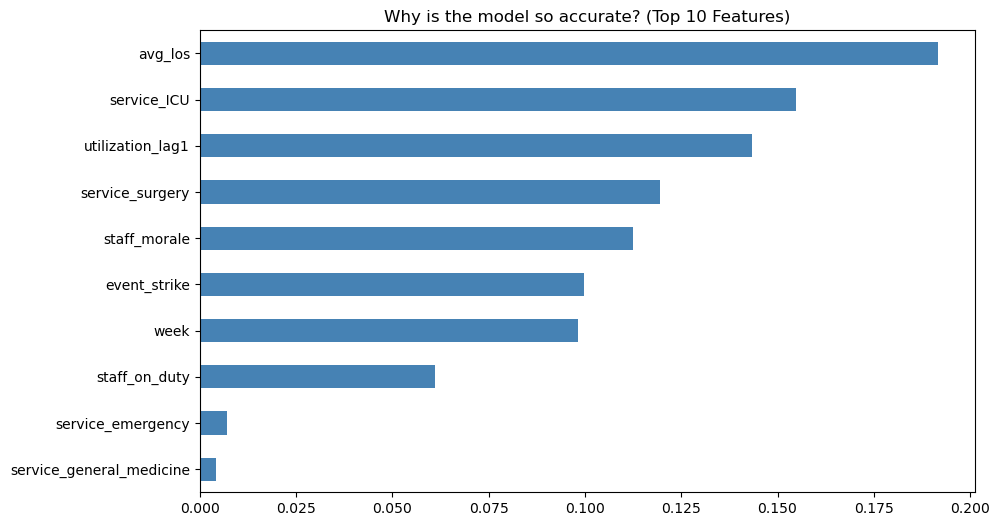

In [47]:
importances = pd.Series(final_model.feature_importances_, index=experimental_features_2)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Why is the model so accurate? (Top 10 Features)')
plt.gca().invert_yaxis()
plt.show()

Now it's clear that the model is utilizing several features to make the predictions. Although MAE increased, the model is now more valuable and actually making predictions based on cause and effect instead of just cheating. Average length of stay as well being the main contributer makes sense, that's because if the patients are staying longer, beds don't free up, and occupancy remains high. Also, the model learnt the effect of different departments on occupancy such as ICU and general medicine. 

## Model Retraining

Since model is now honest, i will retrain it using grid search to find the best parameters to capture those new relationships

In [51]:
param_grid_refined = {
    'n_estimators': [200,300,400],
    'max_depth': [4,5,6],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.8]
}

grid_search_final = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid= param_grid_refined,
    cv= TimeSeriesSplit(n_splits=5),
    scoring = 'neg_mean_absolute_error',
    n_jobs=-1
)

grid_search_final.fit(X_train_new_2, y_train)

print(f"New Best Params: {grid_search_final.best_params_}")
print(f"New Best MAE: {-grid_search_final.best_score_:.4f}")

New Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
New Best MAE: 0.1032


Hyperparameters update shows consistency as well, like for the max depth. When the model had leaky data, it only needed a very simple logic (depth 3). Now that it has to actually understand the relationship between staff morale, strikes, and ICU service types, it required a more complex tree (depth 6) to map out those interactions. Now I will evaluate the final test set MAE.